# Flash-low pipeline benchmark

## Objective

Test whether Flash-low can replace Pro-high in seven existing pipeline stages without materially reducing quality. The four production sources and stored Pro-high outputs are frozen as references; all Flash calls live in a dedicated shadow database.

Success requires more than low cost: outputs must remain parseable by the current pipeline, stable across two repetitions, and at least approximately equivalent under blinded semantic review.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "evals").exists():
    ROOT = ROOT.parent

BENCH = json.loads((ROOT / "evals/pipeline-flash-benchmark-v001.json").read_text())
SUMMARY = json.loads((ROOT / "evals/pipeline-flash-review-v001/summary.json").read_text())
REVIEWS = json.loads((ROOT / "evals/pipeline-flash-review-v001/results.json").read_text())

len(BENCH["cases"]), len(BENCH["trials"]), REVIEWS["review_count"]

(56, 112, 83)

## Method

- 56 frozen cases: two per source in each of seven Pro-high stages.
- 112 real Flash-low calls: two independent repetitions per case.
- Stored Pro outputs were not regenerated and were not treated as infallible gold.
- Three subagents reviewed 83 blinded A/B comparisons. A/B order was randomized per case.
- Mechanical checks cover API failures, pipeline usability, verdict agreement, repetition stability, and observed OpenRouter cost.
- Semantic results are a targeted four-source benchmark, not evidence of domain-general equivalence.

In [2]:
rows = []
for stage, metric in SUMMARY["stages"].items():
    winners = REVIEWS["stages"][stage]["consensus_winners"]
    rows.append({
        "stage": stage,
        "cases": metric["cases"],
        "pro_cost": metric["reference_cost"],
        "flash_cost": metric["flash_cost"]["1"],
        "cost_reduction": 1 - metric["flash_single_cost_ratio"],
        "flash_1_usable": metric["flash_1_usable"],
        "flash_2_usable": metric["flash_2_usable"],
        "pro_wins": winners.get("pro", 0),
        "flash_wins": winners.get("flash", 0),
        "ties": winners.get("tie", 0),
    })
stage_df = pd.DataFrame(rows).sort_values("stage").reset_index(drop=True)
display(stage_df.style.format({
    "pro_cost": "${:.4f}", "flash_cost": "${:.4f}", "cost_reduction": "{:.1%}"
}))

,stage,cases,pro_cost,flash_cost,cost_reduction,flash_1_usable,flash_2_usable,pro_wins,flash_wins,ties
0,kc-statement,8,$0.0079,$0.0011,86.6%,3,0,5,1,2
1,task-generation,8,$0.0613,$0.0053,91.4%,8,8,2,2,4
2,task-granularity,8,$0.0093,$0.0011,88.4%,4,3,4,1,3
3,task-knowledge,8,$0.0062,$0.0009,85.2%,8,8,0,0,8
4,task-revision,8,$0.0143,$0.0012,91.8%,6,6,4,1,3
5,task-substance,8,$0.0161,$0.0013,91.9%,8,8,0,1,7
6,task-triage,8,$0.0090,$0.0038,58.2%,8,8,0,0,8


## Cost and contract validity

One Flash repetition cost about 12% of the selected Pro references overall. The savings are substantial, but a cheap response that the pipeline cannot materialize is not a usable replacement. The second panel therefore shows the stricter contract-validity check.

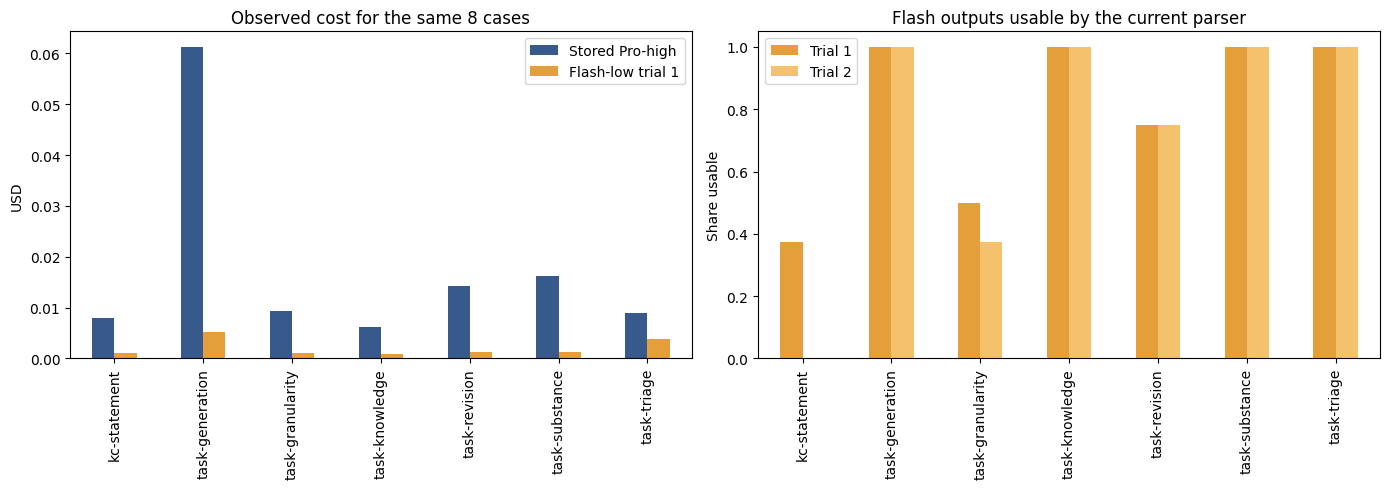

In [3]:
plot_df = stage_df.set_index("stage")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
(plot_df[["pro_cost", "flash_cost"]]
 .plot(kind="bar", ax=axes[0], color=["#38598b", "#e59f3a"]))
axes[0].set_title("Observed cost for the same 8 cases")
axes[0].set_ylabel("USD")
axes[0].set_xlabel("")
axes[0].legend(["Stored Pro-high", "Flash-low trial 1"])

valid = plot_df[["flash_1_usable", "flash_2_usable"]] / 8
valid.plot(kind="bar", ax=axes[1], color=["#e59f3a", "#f4c16d"])
axes[1].set_title("Flash outputs usable by the current parser")
axes[1].set_ylabel("Share usable")
axes[1].set_ylim(0, 1.05)
axes[1].set_xlabel("")
axes[1].legend(["Trial 1", "Trial 2"])
plt.tight_layout()
plt.show()

## Blinded semantic review

Consensus is conservative: directional majority wins; conflicting directional votes remain ties. Pro dominated `kc-statement`, `task-granularity`, and `task-revision`. `task-knowledge` and `task-triage` were all ties. Generation was mixed and evaluator-dependent rather than demonstrably equivalent.

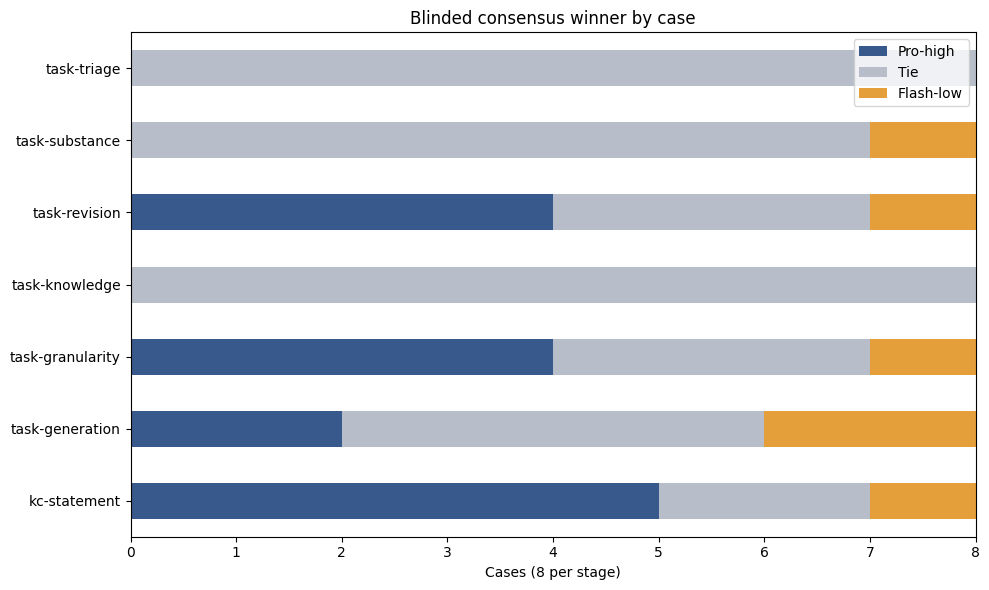

,Pro-high,Tie,Flash-low
stage,,,
kc-statement,5,2,1
task-generation,2,4,2
task-granularity,4,3,1
task-knowledge,0,8,0
task-revision,4,3,1
task-substance,0,7,1
task-triage,0,8,0


In [4]:
review_rows = []
for stage, result in REVIEWS["stages"].items():
    winners = result["consensus_winners"]
    review_rows.append({
        "stage": stage,
        "Pro-high": winners.get("pro", 0),
        "Tie": winners.get("tie", 0),
        "Flash-low": winners.get("flash", 0),
    })
review_df = pd.DataFrame(review_rows).set_index("stage")
review_df[["Pro-high", "Tie", "Flash-low"]].plot(
    kind="barh", stacked=True, figsize=(10, 6),
    color=["#38598b", "#b8bec9", "#e59f3a"]
)
plt.title("Blinded consensus winner by case")
plt.xlabel("Cases (8 per stage)")
plt.ylabel("")
plt.xlim(0, 8)
plt.tight_layout()
plt.show()
display(review_df)

## Decision readout

- **Strongest candidates for a later default change:** `task-knowledge` and `task-triage`. Both were 8/8 usable in both trials, 8/8 internally stable by verdict, and semantically tied with Pro in every reviewed case.
- **Promising but not yet clean:** `task-substance`. Outputs were usable and mostly equivalent, but verdict stability fell to 6/8 and one trial diverged more often from the reference.
- **Inconclusive:** `task-generation`. All responses were structurally valid and much cheaper, but task counts varied and blind reviewers split on coverage, redundancy, and factual quality.
- **Do not switch on this evidence:** `task-granularity`, `task-revision`, and `kc-statement`. They showed missing required fields and/or material quality losses. The second statement trial produced 0/8 usable outputs.

No additional default was changed by this experiment.

In [5]:
assert len(BENCH["cases"]) == 56
assert len(BENCH["trials"]) == 112
assert not any(trial["error"] for trial in BENCH["trials"])
assert BENCH["isolation"]["production_database_written"] is False
assert all(metric["reference_usable"] == 8 for metric in SUMMARY["stages"].values())
assert REVIEWS["case_count"] == 56
print("Integrity checks passed: isolated 56-case corpus, 112 successful calls, 83 blinded reviews.")

Integrity checks passed: isolated 56-case corpus, 112 successful calls, 83 blinded reviews.


## Next step

Keep all non-judge pipeline defaults unchanged for now. If a second experiment is worthwhile, focus spend on cross-domain cases for `task-knowledge` and `task-triage`; separately test a contract-enforced Flash configuration for stages whose optional tool fields were omitted. Do not pool these into one global “Flash replaces Pro” decision.